# Enhanced Comparison: Markowitz vs AI-Gated vs Full Strategy

This notebook provides a detailed comparative analysis of three portfolio management strategies:
1. **Markowitz Only (Baseline)**: Standard Mean-Variance optimization.
2. **AI-Gated Markowitz**: Uses a Random Forest model as a market regime filter (Risk-On/Risk-Off).
3. **Full (AI + Graph + Markowitz)**: Combines AI regime filtering with Graph-based asset selection (MIS) before Markowitz optimization.
4. **Benchmark**: Buy and Hold Bitcoin (BTC).

In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os

# Config Styling
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")
palette = sns.color_palette("viridis", 4)

# Load Data
file_path = 'dataset_2023_2025.xlsx'
if os.path.exists(file_path):
    data = pd.read_excel(file_path, index_col=0, parse_dates=True)
    print(f"✓ Loaded {len(data)} rows of data.")
else:
    print("✗ Data file not found!")

✓ Loaded 990 rows of data.


## 1. AI Market Regime Classifier
We train a Random Forest classifier to predict whether the market will be 'Up' (Bullish) or 'Down' (Bearish) the next day. The 'Gatekeeper' uses these predictions to switch the portfolio to Cash during expected volatility.

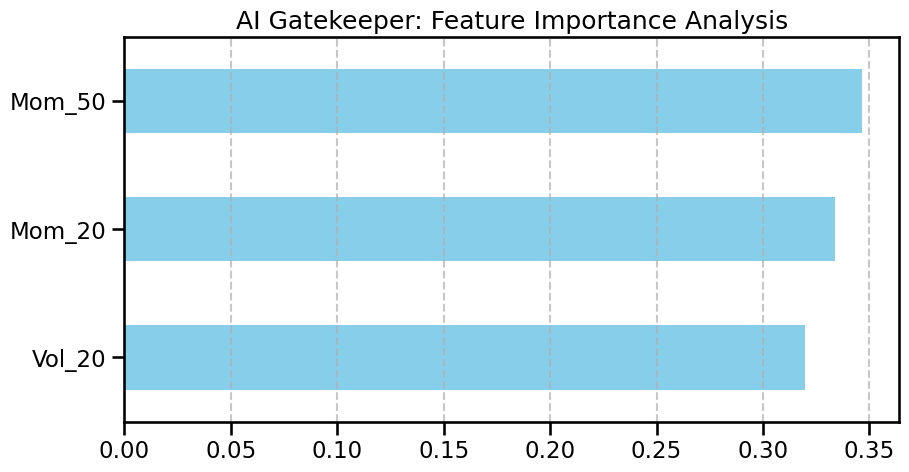

In [12]:
# Returns calculation
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Feature Engineering
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

# Train/Test Split (Backtest on 2025)
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)
X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test, y_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[test_mask, 'Target']

# Training the AI Gatekeeper
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, min_samples_split=10)
rf_model.fit(X_train, y_train)
test_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

# Visualization: Feature Importance
plt.figure(figsize=(10, 5))
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title("AI Gatekeeper: Feature Importance Analysis")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 2. Graph Filter & Markowitz Strategy
The **Graph Filter** identifies a subset of assets that are minimally correlated using the Maximum Independent Set (MIS) algorithm. This reduces systemic risk by avoiding clusters of highly correlated assets.

In [13]:
def get_mis_assets(returns_window, correlation_threshold=0.5):
    """Constructs a correlation graph and finds the Maximum Independent Set (MIS)."""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if corr_mat.iloc[i, j] > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis), G

def optimize_markowitz(selected_returns):
    """Performs Sharpe Ratio maximization."""
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
        
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    
    def neg_sharpe_ratio(weights):
        port_ret = np.sum(weights * mu)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_ret / port_vol if port_vol > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    guess = [1. / len(mu)] * len(mu)
    
    try:
        res = minimize(neg_sharpe_ratio, guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_returns.columns, res.x))
    except:
        return dict(zip(selected_returns.columns, guess))

## 3. Advanced Simulation Engine
We update the simulation to capture **diagnostics** like the current regime, the number of active assets, and the weight distributions.

In [14]:
def run_simulation(strategy_type, test_dates, returns, probs, lookback=30, corr_threshold=0.5):
    current_value = 10000.0
    history = [current_value]
    dates = [test_dates[0]]
    
    # Diagnostic Data
    diag_regimes = []
    diag_n_assets = []
    diag_weights = []
    
    for i, date in enumerate(test_dates[:-1]):
        # 1. Check AI Regime
        is_bull = probs.loc[date] > 0.5 if strategy_type != 'Markowitz Only' else True
        diag_regimes.append(1 if is_bull else 0)
        
        loc_idx = returns.index.get_loc(date)
        if loc_idx < lookback:
            weights = {t: 1.0/len(returns.columns) for t in returns.columns}
        else:
            window_rets = returns.iloc[loc_idx-lookback:loc_idx]
            
            if not is_bull:
                weights = {'CASH': 1.0}
            else:
                if strategy_type == 'Full':
                    selected, _ = get_mis_assets(window_rets, corr_threshold)
                    weights = optimize_markowitz(window_rets[selected])
                else:
                    weights = optimize_markowitz(window_rets)
        
        diag_n_assets.append(len(weights) if 'CASH' not in weights else 0)
        diag_weights.append(weights)
        
        # 2. Daily PnL
        next_date = test_dates[i+1]
        next_rets = returns.loc[next_date]
        
        daily_ret = 0 if 'CASH' in weights else sum(w * next_rets[a] for a, w in weights.items())
        
        current_value *= (1 + daily_ret)
        history.append(current_value)
        dates.append(next_date)
        
    diag = {
        'regimes': pd.Series(diag_regimes, index=test_dates[:-1]),
        'n_assets': pd.Series(diag_n_assets, index=test_dates[:-1]),
        'weights': diag_weights
    }
    return pd.Series(history, index=dates), diag

## 4. Performance Benchmarking
Running the simulations for 2025 and comparing with Bitcoin.

In [15]:
test_dates = X_test.index
print("Backtesting Baseline Markowitz...")
res_m, diag_m = run_simulation('Markowitz Only', test_dates, returns, test_probs)

print("Backtesting AI-Gated Strategy...")
res_a, diag_a = run_simulation('AI-Gated Markowitz', test_dates, returns, test_probs)

print("Backtesting Full (AI + Graph + Markowitz) Strategy...")
res_f, diag_f = run_simulation('Full', test_dates, returns, test_probs)

# Bitcoin Benchmark
btc_val = data.loc[test_dates, 'BTC-USD']
res_btc = btc_val / btc_val.iloc[0] * 10000

strategies = {
    'Markowitz Only': res_m,
    'AI-Gated Markowitz': res_a,
    'Full (AI+Graph+MK)': res_f,
    'BTC Benchmark': res_btc
}

Backtesting Baseline Markowitz...
Backtesting AI-Gated Strategy...
Backtesting Full (AI + Graph + Markowitz) Strategy...


## 5. Visualizations & Explanation

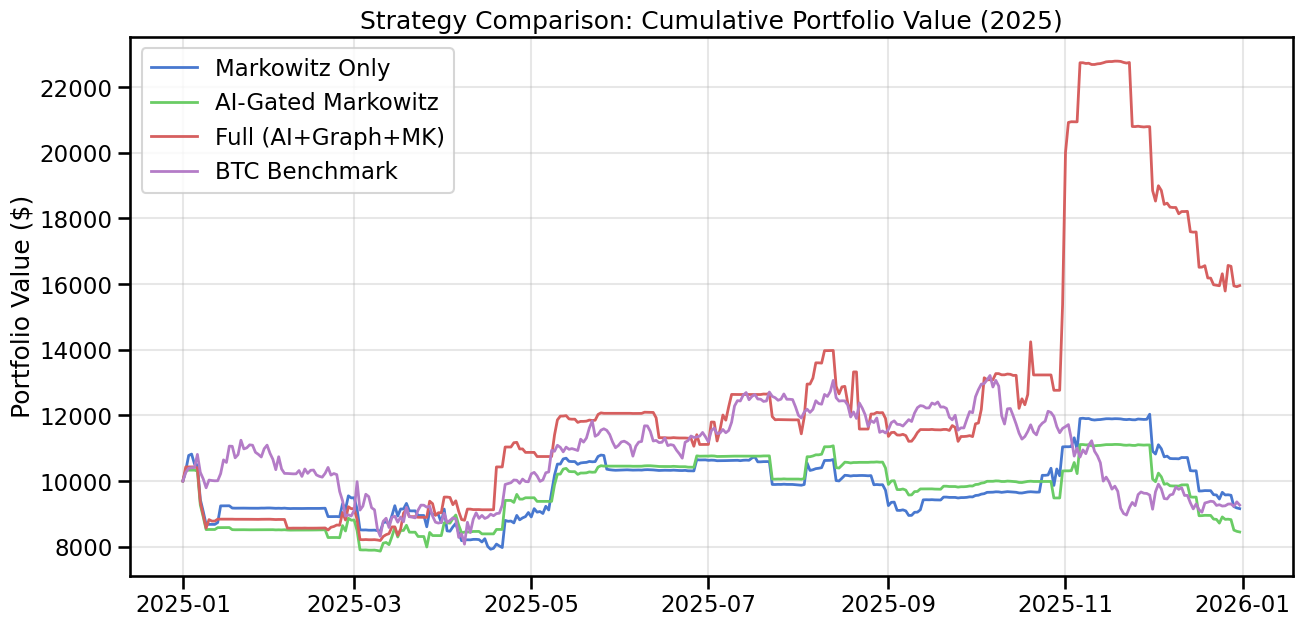

In [16]:
# A. Equity Curve
plt.figure(figsize=(15, 7))
for name, series in strategies.items():
    plt.plot(series, label=name, lw=2)
plt.title("Strategy Comparison: Cumulative Portfolio Value (2025)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

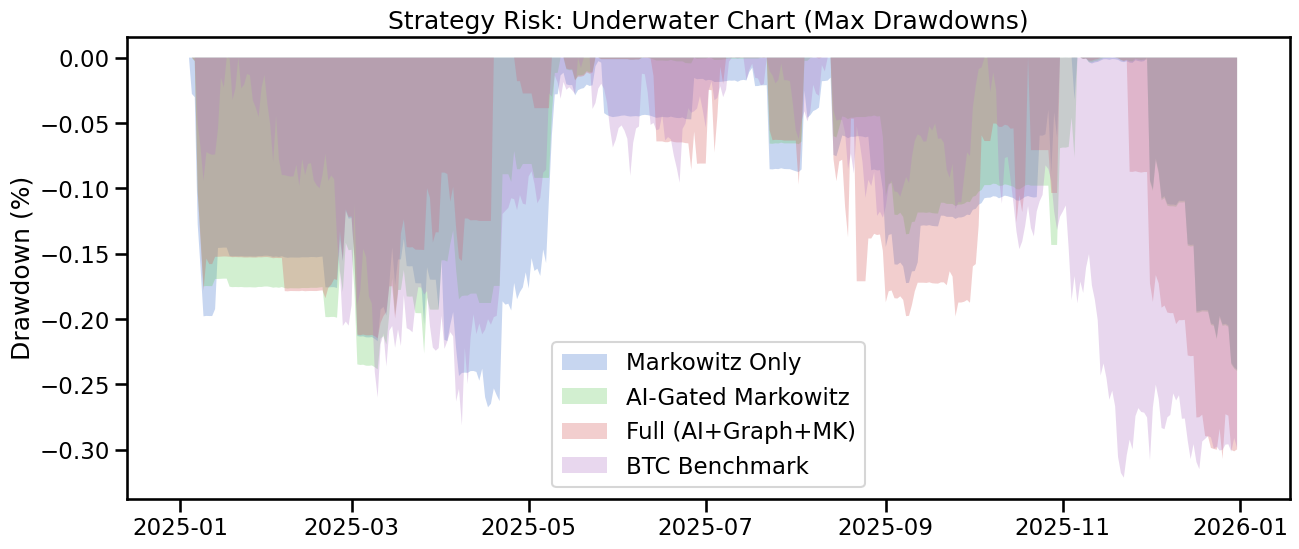

In [17]:
# B. Drawdown Analysis
def get_drawdown(series):
    peaks = series.cummax()
    return (series - peaks) / peaks

plt.figure(figsize=(15, 6))
for name, series in strategies.items():
    dd = get_drawdown(series)
    plt.fill_between(dd.index, dd, label=name, alpha=0.3)
plt.title("Strategy Risk: Underwater Chart (Max Drawdowns)")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.show()

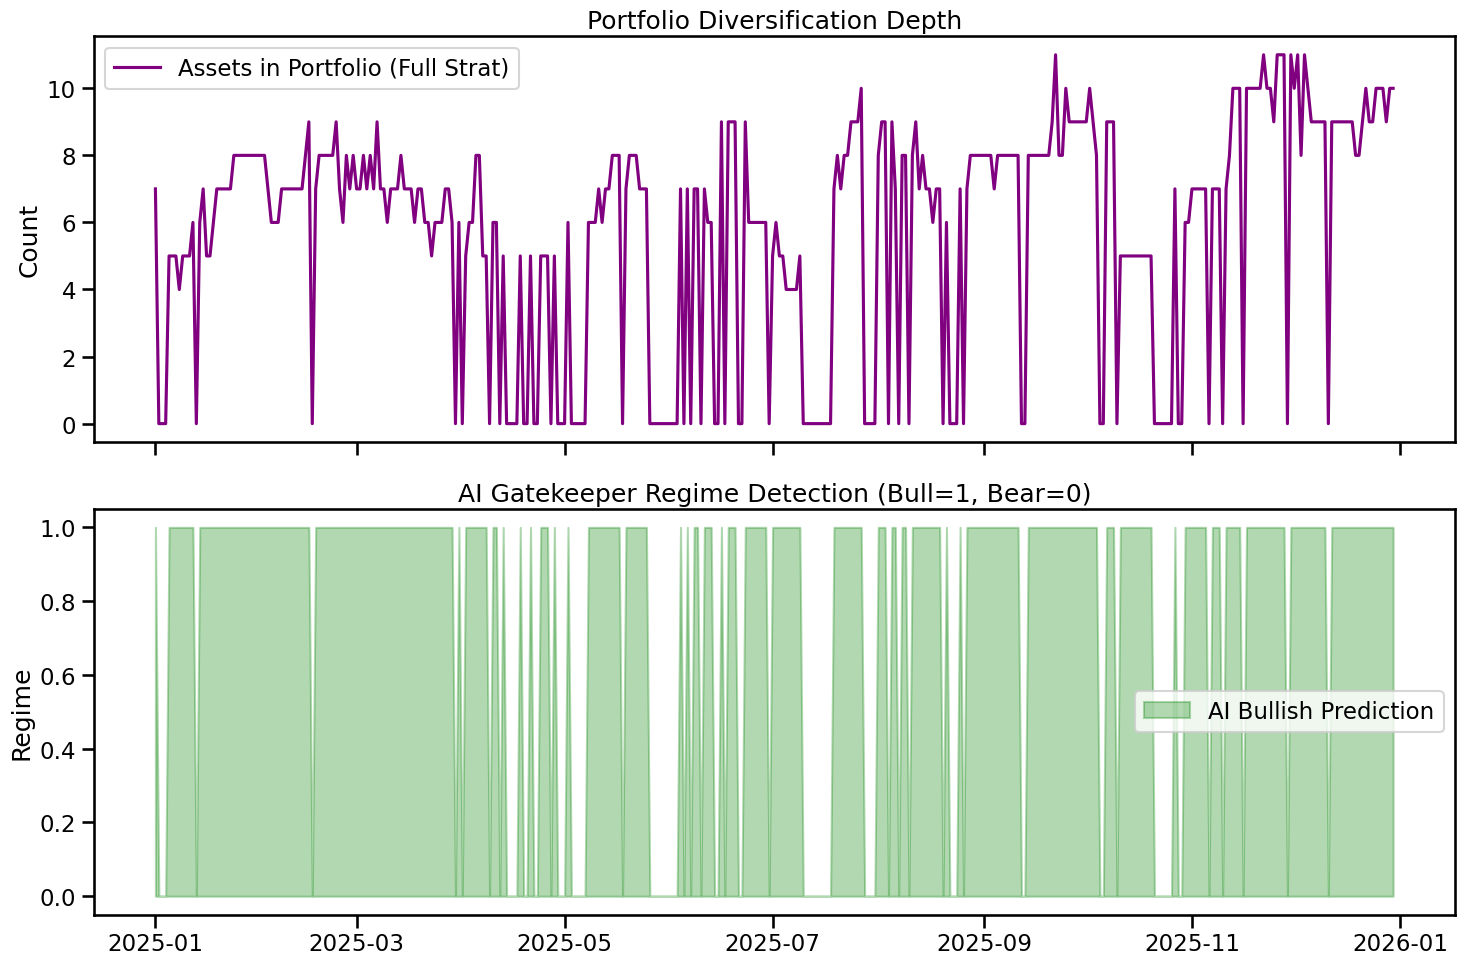

In [18]:
# C. Asset Allocation & Regime Analysis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot number of assets selected over time
ax1.plot(diag_f['n_assets'], color='purple', label="Assets in Portfolio (Full Strat)")
ax1.set_title("Portfolio Diversification Depth")
ax1.set_ylabel("Count")
ax1.legend()

# Plot Predicted Regime
ax2.fill_between(diag_a['regimes'].index, diag_a['regimes'], color='green', alpha=0.3, label="AI Bullish Prediction")
ax2.set_title("AI Gatekeeper Regime Detection (Bull=1, Bear=0)")
ax2.set_ylabel("Regime")
ax2.legend()
plt.tight_layout()
plt.show()

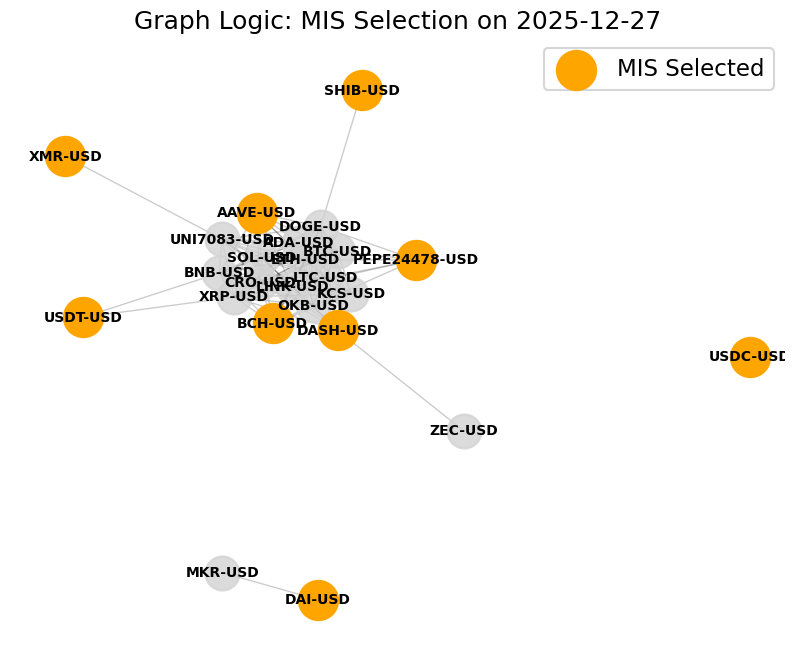

In [19]:
# D. Correlation Graph Visual (Snapshot)
last_date = test_dates[-5]
window_rets = returns.loc[:last_date].tail(30)
selected_assets, G = get_mis_assets(window_rets, 0.5)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightgrey', alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=selected_assets, node_size=800, node_color='orange', label='MIS Selected')
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.2)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title(f"Graph Logic: MIS Selection on {last_date.date()}")
plt.legend()
plt.axis('off')
plt.show()

In [20]:
# E. Performance Summary Table
metrics = []
for name, series in strategies.items():
    rets = series.pct_change().dropna()
    total_ret = (series.iloc[-1] / series.iloc[0] - 1) * 100
    ann_vol = rets.std() * np.sqrt(252) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() != 0 else 0
    max_dd = get_drawdown(series).min() * 100
    
    metrics.append({
        'Strategy': name,
        'Total Return (%)': f"{total_ret:.2f}%",
        'Ann. Volatility (%)': f"{ann_vol:.2f}%",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown (%)': f"{max_dd:.2f}%"
    })

df_metrics = pd.DataFrame(metrics)
print("SUMMARY PERFORMANCE METRICS")
display(df_metrics)

SUMMARY PERFORMANCE METRICS


,Strategy,Total Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
0,Markowitz Only,-8.40%,31.36%,-0.04,-26.76%
1,AI-Gated Markowitz,-15.50%,27.94%,-0.28,-23.98%
2,Full (AI+Graph+MK),59.50%,49.97%,0.88,-30.72%
3,BTC Benchmark,-7.32%,34.87%,0.02,-32.15%
